In [1]:
!pip install yfinance

In [207]:
!pip install ta

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29421 sha256=a282de47234e2983ec5c7cfd523efd0e99cb611efe8054b347b3bf18beafaff3
  Stored in directory: c:\users\gregor\appdata\local\pip\cache\wheels\5c\a1\5f\c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [307]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Téléchargement des données
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
data.reset_index(inplace=True)

data.columns = [col[0] for col in data.columns]

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np
import pandas as pd

C:\Users\GREGOR\AppData\Local\Temp\ipykernel_36272\1995937027.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [309]:
data.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
1,2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2,2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
3,2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
4,2020-01-08,73.153481,73.455080,71.698566,71.698566,132079200


In [311]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [313]:
data.describe()

,Date,Close,High,Low,Open,Volume
count,1488,1488.000000,1488.000000,1488.000000,1488.000000,1.488000e+03
mean,2022-12-16 03:00:58.064515840,163.456008,165.134359,161.603671,163.282634,8.511961e+07
min,2020-01-02 00:00:00,54.264332,55.263182,51.420154,55.161604,2.013560e+07
25%,2021-06-23 18:00:00,131.046993,132.350978,129.847506,131.409717,5.129060e+07
50%,2022-12-13 12:00:00,162.815094,164.215470,161.027043,162.613411,7.075800e+07
75%,2024-06-07 18:00:00,194.066486,195.836077,192.576390,193.753069,1.010720e+08
max,2025-12-02 00:00:00,286.190002,287.399994,282.630005,283.000000,4.265100e+08
std,NaN,48.358105,48.647032,47.999204,48.283934,5.137420e+07


In [315]:
data.isnull().any()

Date      False
Close     False
High      False
Low       False
Open      False
Volume    False
dtype: bool

In [317]:
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # Cible = tendance (1 si hausse, 0 si baisse)

In [319]:
print (data)

           Date       Close        High         Low        Open     Volume  \
0    2020-01-02   72.468262   72.528582   71.223259   71.476600  135480400   
1    2020-01-03   71.763725   72.523754   71.539337   71.696167  146322800   
2    2020-01-06   72.335556   72.374162   70.634539   70.885472  118387200   
3    2020-01-07   71.995354   72.600960   71.775789   72.345204  108872000   
4    2020-01-08   73.153481   73.455080   71.698566   71.698566  132079200   
...         ...         ...         ...         ...         ...        ...   
1483 2025-11-25  276.970001  280.380005  275.250000  275.269989   46914200   
1484 2025-11-26  277.549988  279.529999  276.630005  276.959991   33431400   
1485 2025-11-28  278.850006  279.000000  275.989990  277.260010   20135600   
1486 2025-12-01  283.100006  283.420013  276.140015  278.010010   46587700   
1487 2025-12-02  286.190002  287.399994  282.630005  283.000000   53615500   

      Target  
0          0  
1          1  
2          0  
3  

In [321]:
data["Return"] = data["Close"].pct_change() #Calcul du rendement journalier
data["Volatility"] = data["Return"].rolling(5).std() #Volatilité sur 5 jours = écart-type des rendements
data["MA5"] = data["Close"].rolling(5).mean() #Moyenne mobile courte (5 jours)
data["MA20"] = data["Close"].rolling(20).mean() #Moyenne mobile longue (20 jours)

from ta.momentum import RSIIndicator
data["RSI14"] = RSIIndicator(data["Close"], window=14).rsi() #Le RSI mesure le momentum <30 risque de hausse >70 risque de baisse


In [323]:
data = data.dropna()
print(data)

           Date       Close        High         Low        Open     Volume  \
19   2020-01-30   78.143158   78.196240   76.907809   77.339701  126743200   
20   2020-01-31   74.678383   77.856028   74.384022   77.433789  199588400   
21   2020-02-03   74.473297   75.638673   72.919457   73.421315  173788400   
22   2020-02-04   76.931938   77.122551   75.672459   76.077807  136616400   
23   2020-02-05   77.559265   78.357899   76.956067   78.058708  118826800   
...         ...         ...         ...         ...         ...        ...   
1483 2025-11-25  276.970001  280.380005  275.250000  275.269989   46914200   
1484 2025-11-26  277.549988  279.529999  276.630005  276.959991   33431400   
1485 2025-11-28  278.850006  279.000000  275.989990  277.260010   20135600   
1486 2025-12-01  283.100006  283.420013  276.140015  278.010010   46587700   
1487 2025-12-02  286.190002  287.399994  282.630005  283.000000   53615500   

      Target    Return  Volatility         MA5        MA20     

In [325]:
X = data[["Open", "High", "Low", "Close", "Volume", "Return", "Volatility", "MA5", "MA20", "RSI14"]]
y = data["Target"]

In [327]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Dans un data financier, KFold fait des mélanges de dates, prend du futur pour prédire du passé, fuite de données (data leakage)
exemple : Fold 1 train: 2019-2021 et Fold 1 test : 2015 ce qui est pas possible pour avoir un model réaliste donc on utilise TimeSeriesSplit

In [330]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [332]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {"max_depth": [3, 5, 7, 10, None],"min_samples_split": [2, 5, 10, 20],"min_samples_leaf": [1, 2, 5, 10],
                "criterion": ["gini", "entropy"],"max_features": [None, "sqrt", "log2"]}

grid = GridSearchCV(model_dt,param_grid,cv=tscv,scoring="f1",n_jobs=-1, verbose=1,refit=True)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

Recherche des meilleur parametre

In [335]:
print("Meilleurs paramètres DTC:", grid.best_params_)
print("Best CV DTC F1-score :", grid.best_score_)
best_dt = grid.best_estimator_

Meilleurs paramètres DTC: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV DTC F1-score : 0.5761495687530791


on evalue

In [338]:
y_pred = best_dt.predict(X_test)
auc_dt = roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1])
print("F1-score test :", f1_score(y_test, y_pred))
print("AUC Decision Tree :", auc_dt)
print("\nClassification Report :\n", classification_report(y_test, y_pred))

F1-score test : 0.6184971098265896
AUC Decision Tree : 0.5354224069490496

Classification Report :
               precision    recall  f1-score   support

           0       0.50      0.41      0.45       133
           1       0.58      0.66      0.62       161

    accuracy                           0.55       294
   macro avg       0.54      0.54      0.54       294
weighted avg       0.54      0.55      0.54       294



Matrice de confusion

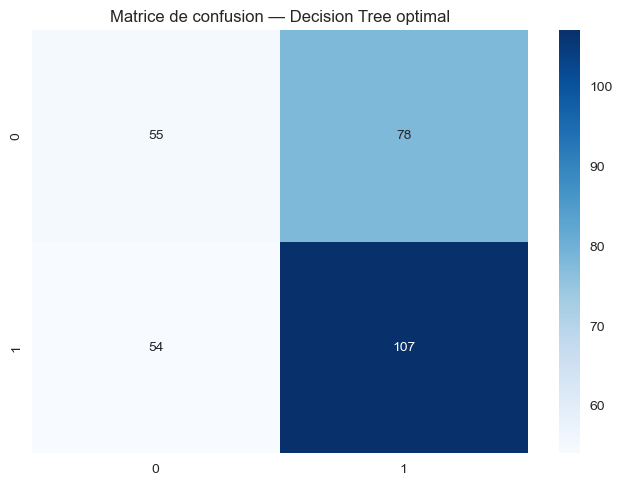

In [341]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Matrice de confusion — Decision Tree optimal")
plt.show()

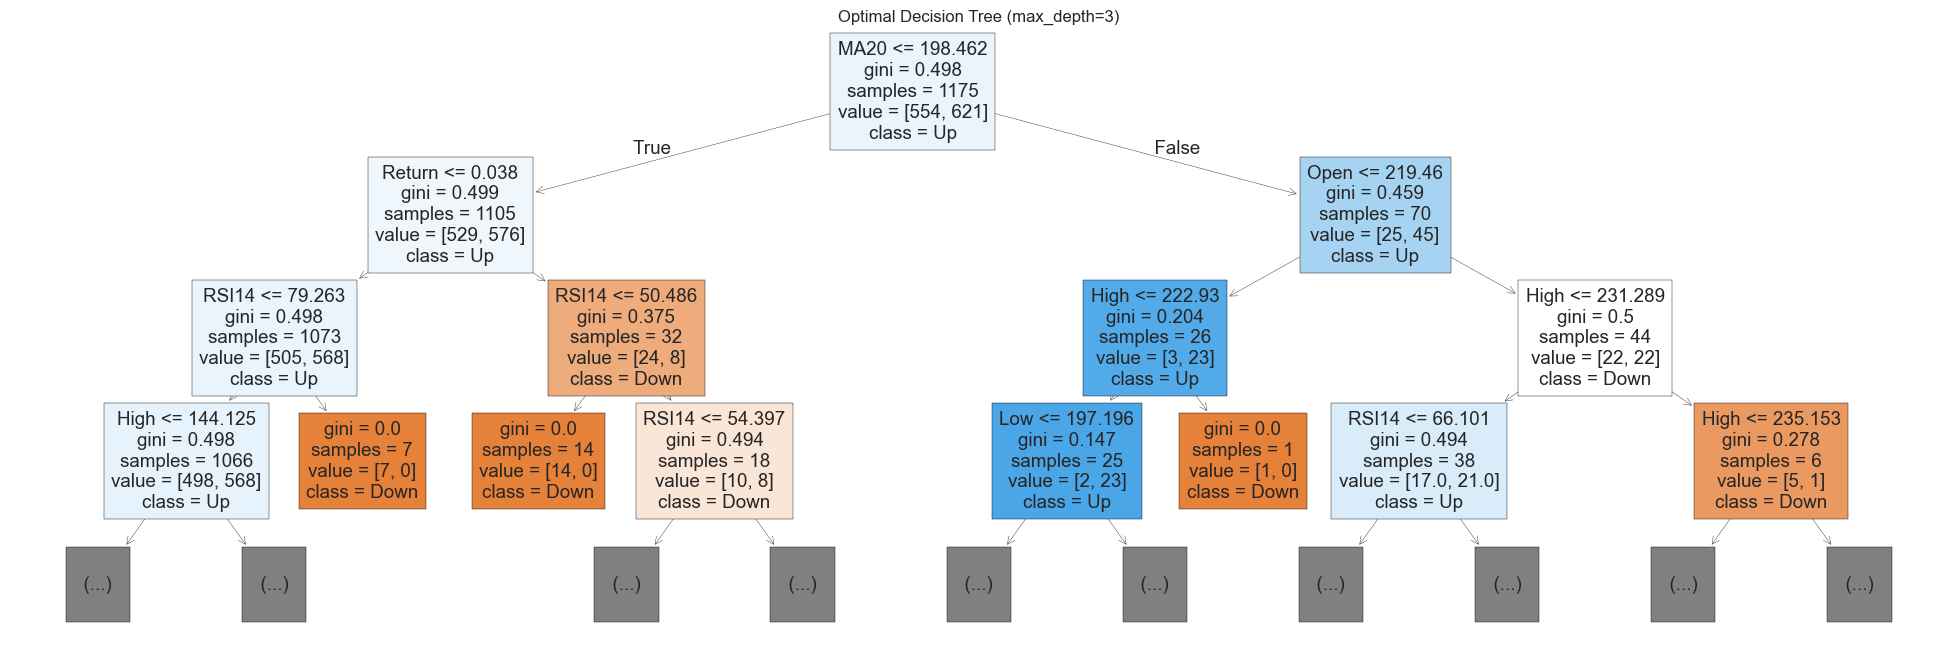

In [343]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_dt = grid.best_estimator_
plt.figure(figsize=(25, 8))
plot_tree(best_dt, max_depth=3, filled=True, feature_names=X_train.columns, class_names=["Down", "Up"])
plt.title("Optimal Decision Tree (max_depth=3)")
plt.show()

Random Forest Classifier avec GridSearchCV

In [346]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid_rf = {"max_depth": [5, 8, 12, None],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4],
                "n_estimators": [100, 200, 400],"max_features": [None, "sqrt", "log2"]}

grid_rf = GridSearchCV(model_rf,param_grid_rf,cv=tscv,scoring="f1",n_jobs=-1, verbose=1,refit=True)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 8, 12, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 400]},
             scoring='f1', verbose=1)

In [348]:
print("Meilleurs paramètres rf:", grid_rf.best_params_)
print("Best CV rf F1-score :", grid_rf.best_score_)
best_rf = grid_rf.best_estimator_

Meilleurs paramètres rf: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV rf F1-score : 0.4192817283791442


Importances des features

C:\Users\GREGOR\AppData\Local\Temp\ipykernel_36272\3296596733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


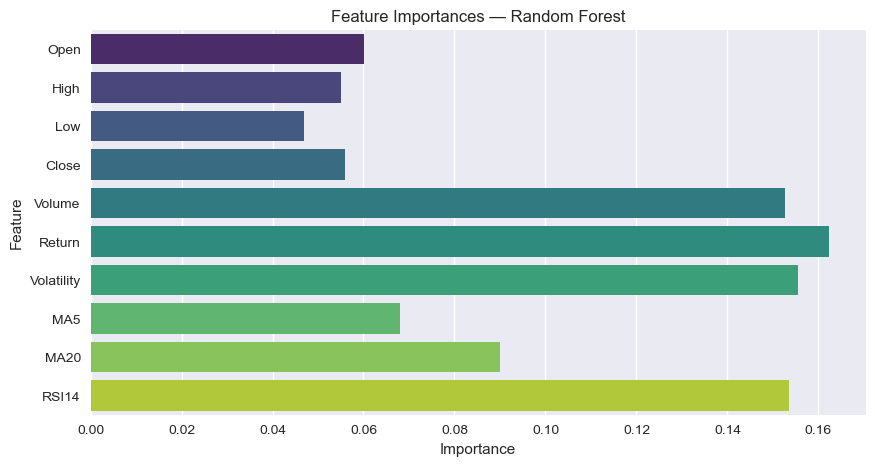

In [351]:
importances = best_rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Evaluation sur le test

In [354]:
y_pred_rf = best_rf.predict(X_test)
auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
print("AUC Random Forest :", auc_rf)
print("F1-score test :", f1_score(y_test, y_pred_rf))
print("\nClassification Report :\n", classification_report(y_test, y_pred_rf))

AUC Random Forest : 0.49518983794890953
F1-score test : 0.42585551330798477

Classification Report :
               precision    recall  f1-score   support

           0       0.45      0.65      0.54       133
           1       0.55      0.35      0.43       161

    accuracy                           0.49       294
   macro avg       0.50      0.50      0.48       294
weighted avg       0.51      0.49      0.48       294



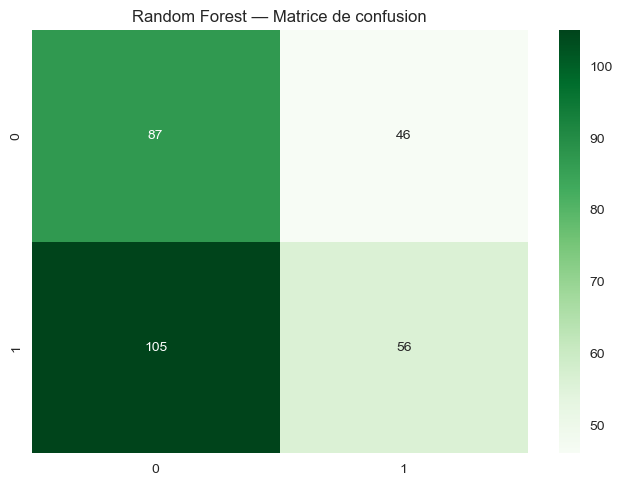

In [355]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, cmap="Greens", fmt="d")
plt.title("Random Forest — Matrice de confusion")
plt.show()

BaggingClassifier (avec Decision Tree)

In [359]:
from sklearn.ensemble import BaggingClassifier

bag_dt = BaggingClassifier(estimator= DecisionTreeClassifier(random_state=42), random_state=42, n_jobs=-1)

param_grid_bag_dt = {"n_estimators": [10, 30, 50, 80],"max_samples": [0.5, 0.7, 1.0],"max_features": [0.5, 0.7, 1.0],"estimator__max_depth": [3, 5, 8, None],
                "estimator__min_samples_split": [2, 5, 10],"estimator__min_samples_leaf": [1, 2, 5]}

grid_bag_dt = GridSearchCV(bag_dt,param_grid_bag_dt,cv=tscv,scoring="f1", n_jobs = -1,verbose=1,refit=True)

grid_bag_dt.fit(X_train, y_train)

print("Meilleurs paramètres Bagging dt :", grid_bag_dt.best_params_)
print("Best CV F1-score Bagging dt :", grid_bag_dt.best_score_)


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Meilleurs paramètres Bagging dt : {'estimator__max_depth': 5, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 10, 'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 10}
Best CV F1-score Bagging dt : 0.5475938609137211


In [361]:
best_bag_dt = grid_bag_dt.best_estimator_
y_pred_bag_dt = best_bag_dt.predict(X_test)
auc_bag_dt = roc_auc_score(y_test, best_bag_dt.predict_proba(X_test)[:,1])
print("AUC Bagging (DT) :", auc_bag_dt)
print("F1-score test Bagging (DT) :", f1_score(y_test, y_pred_bag_dt))
print("\nClassification Report :\n", classification_report(y_test, y_pred_bag_dt))

AUC Bagging (DT) : 0.547634614486527
F1-score test Bagging (DT) : 0.573208722741433

Classification Report :
               precision    recall  f1-score   support

           0       0.49      0.49      0.49       133
           1       0.57      0.57      0.57       161

    accuracy                           0.53       294
   macro avg       0.53      0.53      0.53       294
weighted avg       0.53      0.53      0.53       294



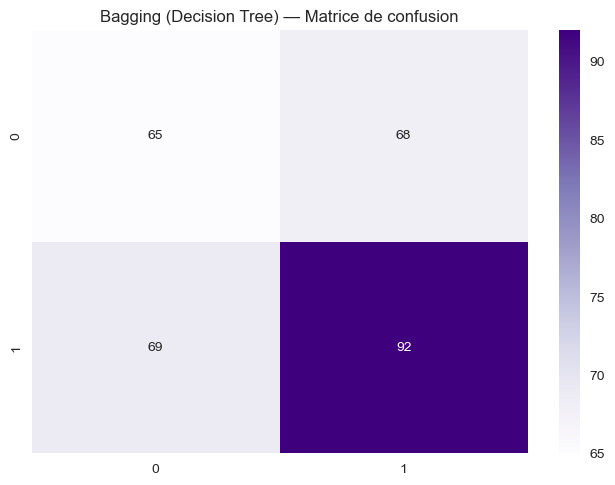

In [363]:
cm_dt = confusion_matrix(y_test, y_pred_bag_dt)
sns.heatmap(cm_dt, annot=True, cmap="Purples", fmt="d")
plt.title("Bagging (Decision Tree) — Matrice de confusion")
plt.show()

BaggingClassifier (avec RandomForestClassifier)

In [366]:
bag_rf = BaggingClassifier(estimator= RandomForestClassifier(random_state=42, class_weight="balanced",n_jobs=-1), random_state=42, n_jobs=-1)

param_grid_bag_rf = {"n_estimators": [5, 10, 20],"max_samples": [0.5, 0.7, 1.0],"max_features": [0.5, 0.7, 1.0], "estimator__n_estimators": [100, 200],
                     "estimator__max_depth": [8, 12, None], "estimator__min_samples_split": [2, 5, 10],"estimator__min_samples_leaf": [1, 2, 4]}

grid_bag_rf = GridSearchCV(bag_rf,param_grid_bag_rf,cv=tscv,scoring="f1", n_jobs = -1,verbose=1,refit=True)

grid_bag_rf.fit(X_train, y_train)

print("Meilleurs paramètres Bagging rf :", grid_bag_rf.best_params_)
print("Best CV F1-score Bagging rf :", grid_bag_rf.best_score_)

Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
Meilleurs paramètres Bagging rf : {'estimator__max_depth': 12, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 100, 'max_features': 0.7, 'max_samples': 0.5, 'n_estimators': 5}
Best CV F1-score Bagging rf : 0.4241094222638183


In [368]:
best_bag_rf = grid_bag_rf.best_estimator_
y_pred_bag_rf = best_bag_rf.predict(X_test)
auc_bag_rf = roc_auc_score(y_test, best_bag_rf.predict_proba(X_test)[:,1])
print("AUC Bagging (RF) :", auc_bag_rf)
print("F1-score test Bagging (RF) :", f1_score(y_test, y_pred_bag_rf))
print("\nClassification Report :\n", classification_report(y_test, y_pred_bag_rf))

AUC Bagging (RF) : 0.48517255872600756
F1-score test Bagging (RF) : 0.41825095057034223

Classification Report :
               precision    recall  f1-score   support

           0       0.45      0.65      0.53       133
           1       0.54      0.34      0.42       161

    accuracy                           0.48       294
   macro avg       0.49      0.49      0.47       294
weighted avg       0.50      0.48      0.47       294



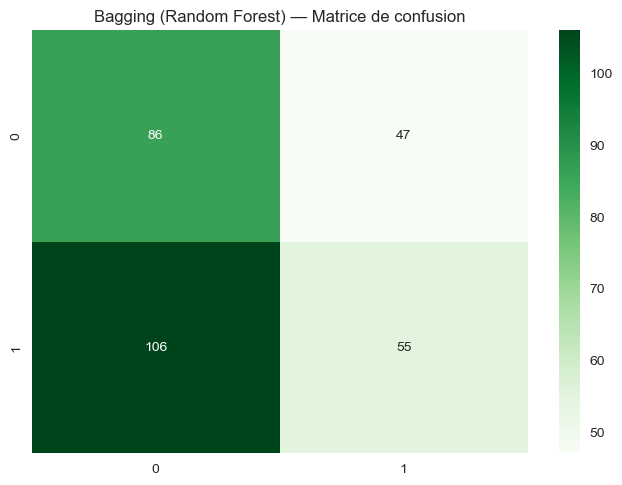

In [370]:
cm_rf = confusion_matrix(y_test, y_pred_bag_rf)
sns.heatmap(cm_rf, annot=True, cmap="Greens", fmt="d")
plt.title("Bagging (Random Forest) — Matrice de confusion")
plt.show()

Hard Voting

F1-score Hard Voting : 0.5612903225806452

Classification Report :
               precision    recall  f1-score   support

           0       0.49      0.53      0.51       133
           1       0.58      0.54      0.56       161

    accuracy                           0.54       294
   macro avg       0.54      0.54      0.54       294
weighted avg       0.54      0.54      0.54       294



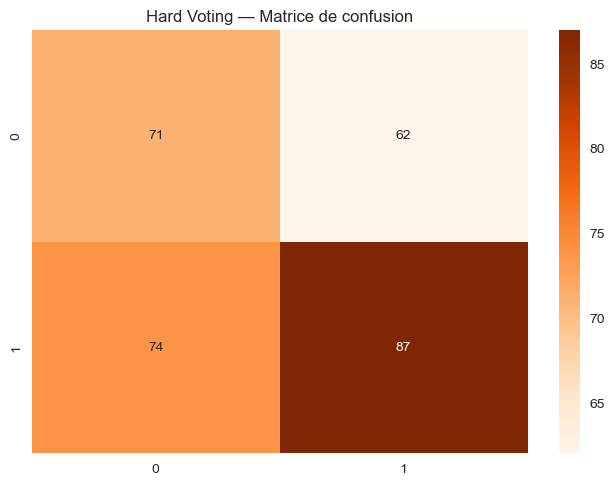

In [376]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(estimators=[("dt", best_dt),("rf", best_rf),("bag", best_bag_dt)],voting="hard",n_jobs=-1)

voting_hard.fit(X_train, y_train)



print("F1-score Hard Voting :", f1_score(y_test, y_pred_vh))
print("\nClassification Report :\n", classification_report(y_test, y_pred_vh))

cm_vh = confusion_matrix(y_test, y_pred_vh)
sns.heatmap(cm_vh, annot=True, cmap="Oranges", fmt="d")
plt.title("Hard Voting — Matrice de confusion")
plt.show()

AUC Voting Soft : 0.5596366693130341
F1-score Soft Voting : 0.6029850746268657

Classification Report :
               precision    recall  f1-score   support

           0       0.50      0.45      0.47       133
           1       0.58      0.63      0.60       161

    accuracy                           0.55       294
   macro avg       0.54      0.54      0.54       294
weighted avg       0.54      0.55      0.54       294



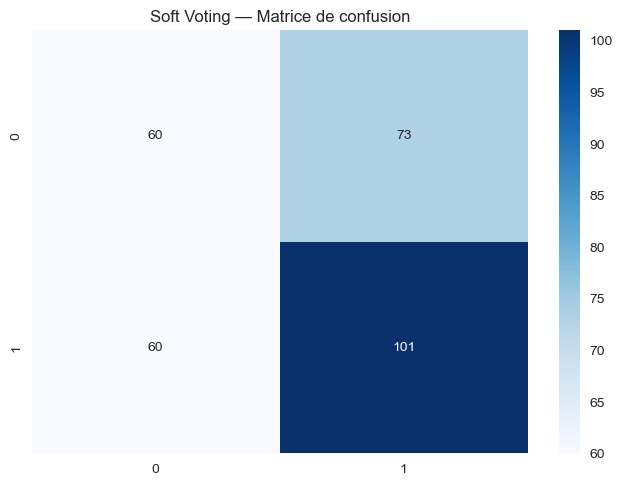

In [378]:

voting_soft = VotingClassifier(estimators=[("dt", best_dt),("rf", best_rf),("bag", best_bag_dt)],voting="soft",n_jobs=-1,weights=[1, 2, 2])

voting_soft.fit(X_train, y_train)

y_pred_vs = voting_soft.predict(X_test)
auc_vs = roc_auc_score(y_test, voting_soft.predict_proba(X_test)[:,1])
print("AUC Voting Soft :", auc_vs)
print("F1-score Soft Voting :", f1_score(y_test, y_pred_vs))
print("\nClassification Report :\n", classification_report(y_test, y_pred_vs))

cm_vs = confusion_matrix(y_test, y_pred_vs)
sns.heatmap(cm_vs, annot=True, cmap="Blues", fmt="d")
plt.title("Soft Voting — Matrice de confusion")
plt.show() 


AUC Stacking : 0.5036426469901462
F1-score Stacking : 0.6074498567335244

Classification Report :
               precision    recall  f1-score   support

           0       0.48      0.38      0.43       133
           1       0.56      0.66      0.61       161

    accuracy                           0.53       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.53      0.53      0.53       294



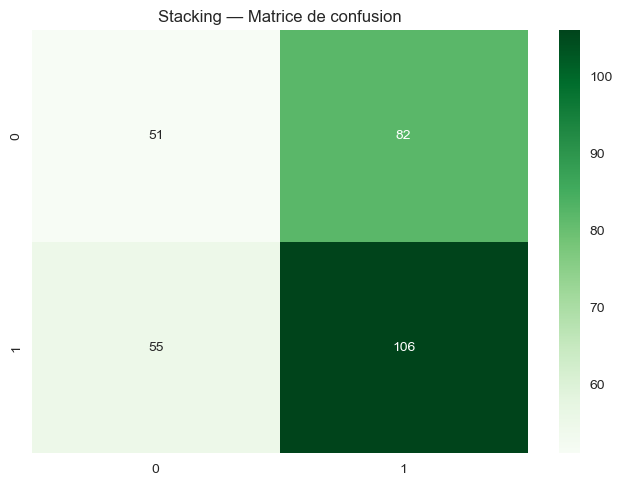

In [380]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(estimators=[("dt", best_dt),("rf", best_rf),("bag", best_bag_dt)],final_estimator=LogisticRegression(max_iter=500,
                              class_weight="balanced"), n_jobs=-1,passthrough=False)
stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)
auc_stack = roc_auc_score(y_test, stacking.predict_proba(X_test)[:,1])
print("AUC Stacking :", auc_stack)

print("F1-score Stacking :", f1_score(y_test, y_pred_stack))
print("\nClassification Report :\n", classification_report(y_test, y_pred_stack))

cm_st = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm_st, annot=True, cmap="Greens", fmt="d")
plt.title("Stacking — Matrice de confusion")
plt.show()

Model Markovien

On utilise le y_train pour estimer la matrice de transition

In [384]:

y_train_markov = y_train.reset_index(drop=True)
y_test_markov = y_test.reset_index(drop=True)

p11 = ((y_train_markov.shift(1) == 1) & (y_train_markov == 1)).sum() / (y_train_markov.shift(1) == 1).sum()
p10 = 1 - p11

p01 = ((y_train_markov.shift(1) == 0) & (y_train_markov == 1)).sum() / (y_train_markov.shift(1) == 0).sum()
p00 = 1 - p01

transition_matrix = np.array([[p11, p10],[p01, p00]])

print("\nMATRICE DE TRANSITION MARKOV\n")
print(pd.DataFrame(transition_matrix,index=["Etat courant = 1", "Etat courant = 0"],columns=["Prochain = 1", "Prochain = 0"]))


MATRICE DE TRANSITION MARKOV

                  Prochain = 1  Prochain = 0
Etat courant = 1      0.515298      0.484702
Etat courant = 0      0.544304      0.455696


PREDICTION MARKOV

In [387]:
# On prédit y_test à partir de y_test décalé
last_values = y_test_markov.shift(1)

pred_markov_prob = last_values.map({1: p11, 0: p01}).fillna(0.5)  # par sécurité pour la 1re valeur

pred_markov = (pred_markov_prob > 0.5).astype(int)


SCORES MARKOV

In [390]:
f1_markov = f1_score(y_test_markov, pred_markov)
auc_markov = roc_auc_score(y_test_markov, pred_markov_prob)

print("\n===== SCORE MARKOV =====")
print("F1 Markov :", f1_markov)
print("AUC Markov :", auc_markov)



===== SCORE MARKOV =====
F1 Markov : 0.7048458149779736
AUC Markov : 0.4689674496801009


VERSION LISSEE (MOYENNAGE)

In [393]:
pred_markov_smooth_prob = pred_markov_prob.rolling(5).mean().fillna(pred_markov_prob)
pred_markov_smooth = (pred_markov_smooth_prob > 0.5).astype(int)

f1_markov_smooth = f1_score(y_test_markov, pred_markov_smooth)
auc_markov_smooth = roc_auc_score(y_test_markov, pred_markov_smooth_prob)

print("\n===== SCORE MARKOV LISSE (window = 5) =====")
print("F1 Markov Smooth :", f1_markov_smooth)
print("AUC Markov Smooth :", auc_markov_smooth)

# On stocke pour la partie corrélation
y_pred_markov = pred_markov.reset_index(drop=True)
y_pred_markov_smooth = pred_markov_smooth.reset_index(drop=True)


===== SCORE MARKOV LISSE (window = 5) =====
F1 Markov Smooth : 0.7048458149779736
AUC Markov Smooth : 0.4768598514920842


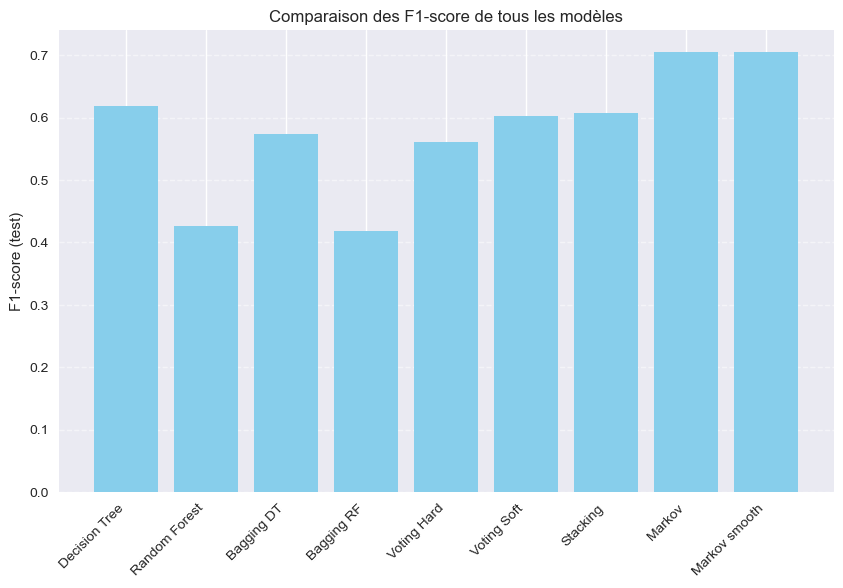

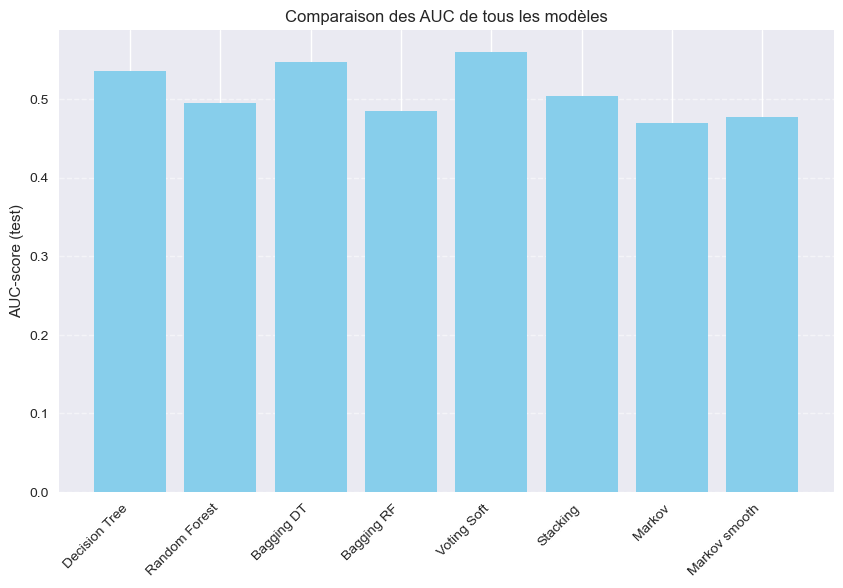

In [407]:

model_names = ["Decision Tree","Random Forest","Bagging DT","Bagging RF","Voting Hard","Voting Soft","Stacking", "Markov", "Markov smooth"]

f1_scores = [f1_score(y_test, y_pred),f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_bag_dt), f1_score(y_test, y_pred_bag_rf),
                f1_score(y_test, y_pred_vh),f1_score(y_test, y_pred_vs), f1_score(y_test, y_pred_stack), f1_markov,f1_markov_smooth]

model_name= ["Decision Tree","Random Forest","Bagging DT","Bagging RF","Voting Soft","Stacking", "Markov", "Markov smooth"]
auc_scores = [auc_dt,auc_rf,auc_bag_dt,auc_bag_rf, auc_vs,auc_stack,auc_markov, auc_markov_smooth]

plt.figure(figsize=(10,6))
plt.bar(model_names, f1_scores, color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score (test)")
plt.title("Comparaison des F1-score de tous les modèles")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(10,6))
plt.bar(model_name,auc_scores , color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC-score (test)")
plt.title("Comparaison des AUC de tous les modèles")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


CORRÉLATIONS POUR TOUS LES MODÈLES

In [424]:
import pandas as pd
# Return réel continu aligné avec y_test
n_test = len(y_test)

real_return = data["Return"].iloc[-n_test:].reset_index(drop=True)
real_binary = y_test.reset_index(drop=True)


# Dictionnaire des prédictions de tous tes modèles
all_preds = {
    "Decision Tree": pd.Series(y_pred),
    "Random Forest": pd.Series(y_pred_rf),
    "Bagging DT": pd.Series(y_pred_bag_dt),
    "Bagging RF": pd.Series(y_pred_bag_rf),
    "Voting Soft": pd.Series(y_pred_vs),
    "Stacking": pd.Series(y_pred_stack),
}



CALCUL DES CORRÉLATIONS

In [427]:
corr_table = []

for name, pred in all_preds.items():
    corr_bin = np.corrcoef(pred, real_binary)[0,1]  # Corrélation brute binaire
    corr_ret = np.corrcoef(pred, real_return)[0,1] # Corrélation brute retour continu
    pred_smooth = pred.rolling(5).mean()  # Smoothing (moyenne glissante)
    corr_smooth = pred_smooth.corr(real_return)# Corrélation après smoothing
    corr_table.append([name, corr_bin, corr_ret, corr_smooth])


df_corr = pd.DataFrame(corr_table, columns=["Modèle", "Corr binaire", "Corr return", "Corr smoothing"])
df_corr = df_corr.set_index("Modèle")

print("\n===== Tableau de corrélations =====\n")
display(df_corr)


===== Tableau de corrélations =====



,Corr binaire,Corr return,Corr smoothing
Modèle,,,
Decision Tree,0.080512,-0.011258,-0.056298
Random Forest,0.002051,0.082430,0.062732
Bagging DT,0.060112,0.097131,0.003582
Bagging RF,-0.012306,-0.043875,-0.004143
Voting Soft,0.079452,0.054082,-0.062891
Stacking,0.043375,-0.091448,-0.027766


GRAPHIQUE DE CORRÉLATION GLISSANTE

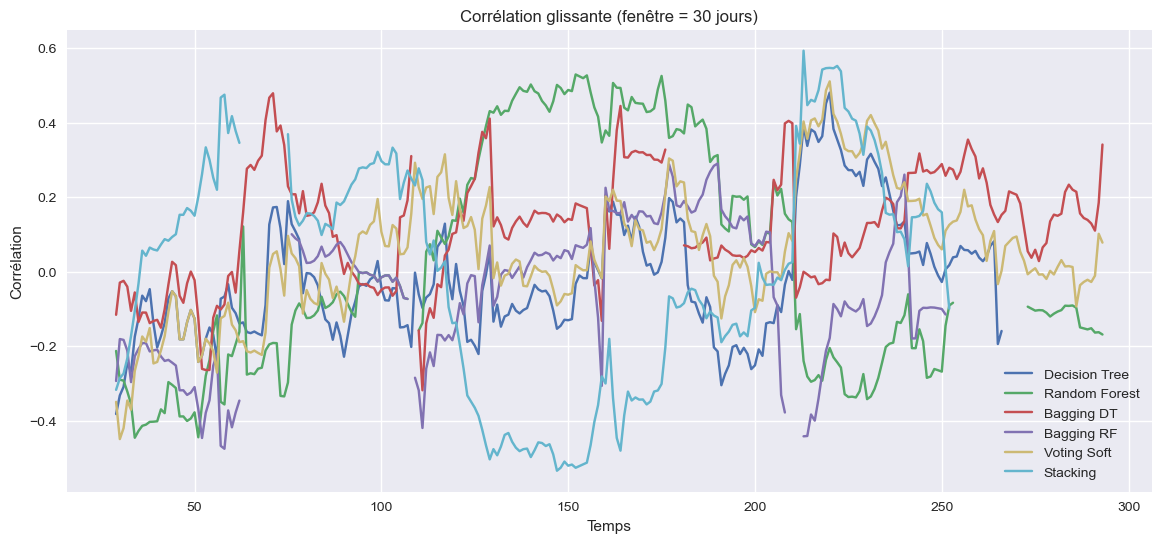

In [430]:
plt.figure(figsize=(14,6))
for name, pred in all_preds.items():
    rc = pred.rolling(30).corr(real_return)
    plt.plot(rc, label=name)

plt.title("Corrélation glissante (fenêtre = 30 jours)")
plt.xlabel("Temps")
plt.ylabel("Corrélation")
plt.grid(True)
plt.legend()
plt.show()